# CSCI 347 - Data Mining Final Project
## Predicting Credit Card Default Risk Using Classification Models
### Ryan Adolph, Braeden Olds, Michael Oswald

**Dataset:** Default of Credit Card Clients, UCI Machine Learning Repository  
**Citation:** Yeh, I. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H

## 1. Problem Overview

The goal of this project is to predict whether a credit card client will default on their payment the following month. This is a supervised binary classification problem.

- Target class `0`: client does not default
- Target class `1`: client defaults

## 2. Stakeholders and Value

**Stakeholders:** banks, credit card companies, financial analysts, risk teams, and customers.

**Project value:** compare classification methods for predicting default risk and identify patterns that may help explain which financial behaviors are associated with higher default risk.

**Ethical note:** credit risk models can affect real people, so the final discussion should acknowledge fairness concerns, especially around demographic features.

## 3. Setup and Imports

In [21]:
# Run this cell before the imports to install packages into the active Jupyter kernel.
%pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 4. Load Dataset

Load the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. Confirm the feature matrix, target variable, and dataset metadata.

In [23]:
# Load the dataset from UCI.
default_credit = fetch_ucirepo(id=350)

X = default_credit.data.features.copy()
y = default_credit.data.targets.copy()

# Rename the UCI X1-X23 columns to the dataset's descriptive feature names.
feature_names = default_credit.variables.loc[
    default_credit.variables["role"] == "Feature", ["name", "description"]
]
rename_map = dict(zip(feature_names["name"], feature_names["description"]))
X = X.rename(columns=rename_map)

# Convert the target from a one-column DataFrame to a clearly named Series.
y = y.squeeze().rename("default_next_month")

# Keep a combined DataFrame available for inspection and later EDA.
df = X.copy()
df[y.name] = y

print(default_credit.metadata["name"])
print("Dataset DOI:", default_credit.metadata["dataset_doi"])
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(default_credit.variables)

Default of Credit Card Clients
Dataset DOI: 10.24432/C55S3H
Feature matrix shape: (30000, 23)
Target shape: (30000,)


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,None,None,no
1,X1,Feature,Integer,None,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,None,PAY_0,None,no
7,X7,Feature,Integer,None,PAY_2,None,no
8,X8,Feature,Integer,None,PAY_3,None,no
9,X9,Feature,Integer,None,PAY_4,None,no


## 5. Dataset Summary and Initial Inspection

Use this section to document the dataset shape, column names, data types, missing values, duplicate rows, and class balance.

In [24]:
# Inspect dataset shape, feature columns, target column, and data types.
dataset_summary = pd.DataFrame({
    "item": ["Rows", "Input features", "Target column"],
    "value": [df.shape[0], X.shape[1], y.name],
})

display(dataset_summary)
display(X.head())

data_types = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
})
display(data_types)

,item,value
0,Rows,30000
1,Input features,23
2,Target column,default_next_month


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


,column,dtype
0,LIMIT_BAL,int64
1,SEX,int64
2,EDUCATION,int64
3,MARRIAGE,int64
4,AGE,int64
5,PAY_0,int64
6,PAY_2,int64
7,PAY_3,int64
8,PAY_4,int64
9,PAY_5,int64


In [25]:
# Check missing values and duplicate rows.
missing_values = df.isna().sum().sort_values(ascending=False)
missing_table = missing_values.reset_index()
missing_table.columns = ["column", "missing_count"]
missing_table["missing_percent"] = (missing_table["missing_count"] / len(df) * 100).round(2)

duplicate_count = df.duplicated().sum()

display(missing_table)
print("Duplicate rows:", duplicate_count)

,column,missing_count,missing_percent
0,LIMIT_BAL,0,0.0
1,SEX,0,0.0
2,EDUCATION,0,0.0
3,MARRIAGE,0,0.0
4,AGE,0,0.0
5,PAY_0,0,0.0
6,PAY_2,0,0.0
7,PAY_3,0,0.0
8,PAY_4,0,0.0
9,PAY_5,0,0.0


Duplicate rows: 35


,default_next_month,count,percent
0,0,23364,77.88
1,1,6636,22.12


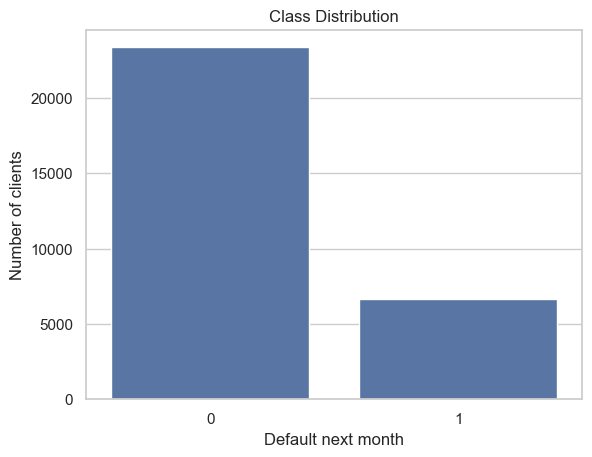

In [26]:
# Inspect class balance for default vs non-default clients.
class_counts = y.value_counts().sort_index()
class_balance = pd.DataFrame({
    "default_next_month": class_counts.index,
    "count": class_counts.values,
    "percent": (class_counts.values / len(y) * 100).round(2),
})

display(class_balance)

ax = sns.barplot(data=class_balance, x="default_next_month", y="count")
ax.set_title("Class Distribution")
ax.set_xlabel("Default next month")
ax.set_ylabel("Number of clients")
plt.show()

## 6. Exploratory Data Analysis

Recommended visuals for this section

- Class balance bar chart
- Age distribution histogram
- Credit limit histogram
- Correlation heatmap
- Boxplots comparing key variables by default status
- Payment history variables compared with default status

In [27]:
# Summary statistics for the numerical features.
summary_stats = X.describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


,default_next_month,count,percent
0,No Default,23364,77.88
1,Default,6636,22.12


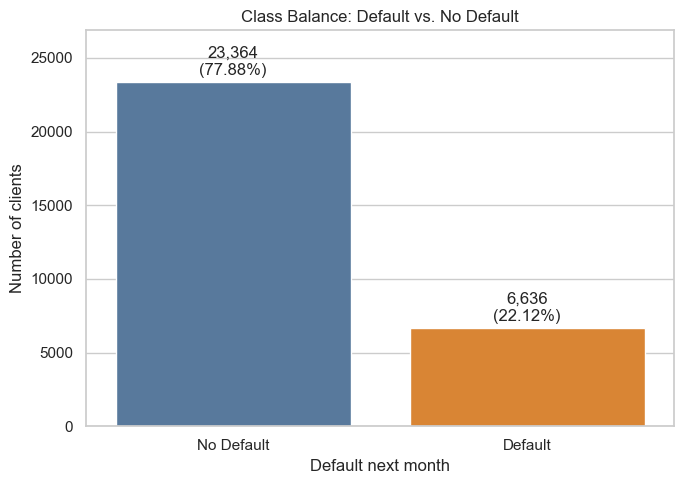

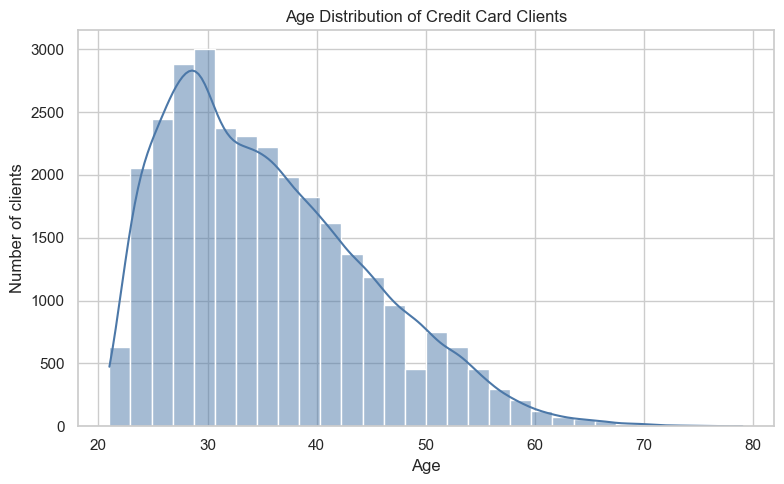

In [28]:
# Class balance bar chart.
class_counts = y.value_counts().sort_index()
class_balance = pd.DataFrame({
    "default_next_month": class_counts.index.map({0: "No Default", 1: "Default"}),
    "count": class_counts.values,
    "percent": (class_counts.values / len(y) * 100).round(2),
})

display(class_balance)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=class_balance,
    x="default_next_month",
    y="count",
    hue="default_next_month",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)

for index, row in class_balance.iterrows():
    ax.text(
        index,
        row["count"] + 300,
        f"{row['count']:,}\n({row['percent']}%)",
        ha="center",
        va="bottom",
    )

ax.set_title("Class Balance: Default vs. No Default")
ax.set_xlabel("Default next month")
ax.set_ylabel("Number of clients")
plt.ylim(0, class_balance["count"].max() * 1.15)
plt.tight_layout()
plt.show()

# Age distribution histogram.
plt.figure(figsize=(8, 5))
sns.histplot(data=X, x="AGE", bins=30, kde=True, color="#4C78A8")
plt.title("Age Distribution of Credit Card Clients")
plt.xlabel("Age")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

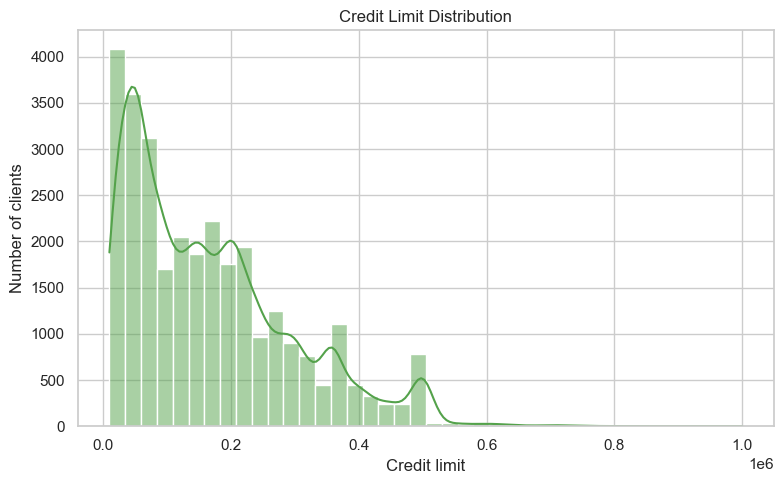

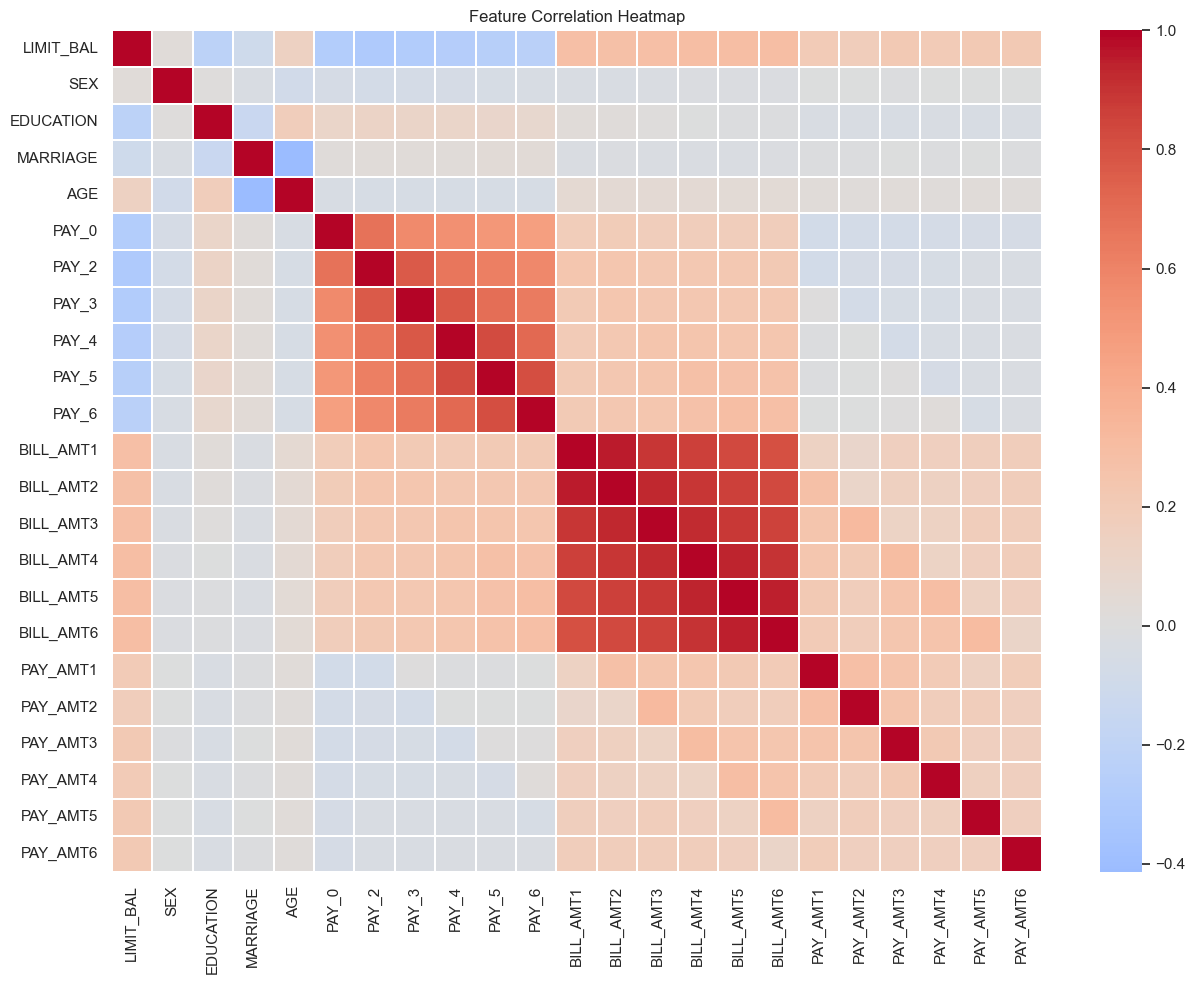

In [29]:
# Credit limit distribution histogram.
plt.figure(figsize=(8, 5))
sns.histplot(data=X, x="LIMIT_BAL", bins=40, kde=True, color="#54A24B")
plt.title("Credit Limit Distribution")
plt.xlabel("Credit limit")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.show()

# Correlation heatmap for numerical features.
plt.figure(figsize=(13, 10))
correlation_matrix = X.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.25)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

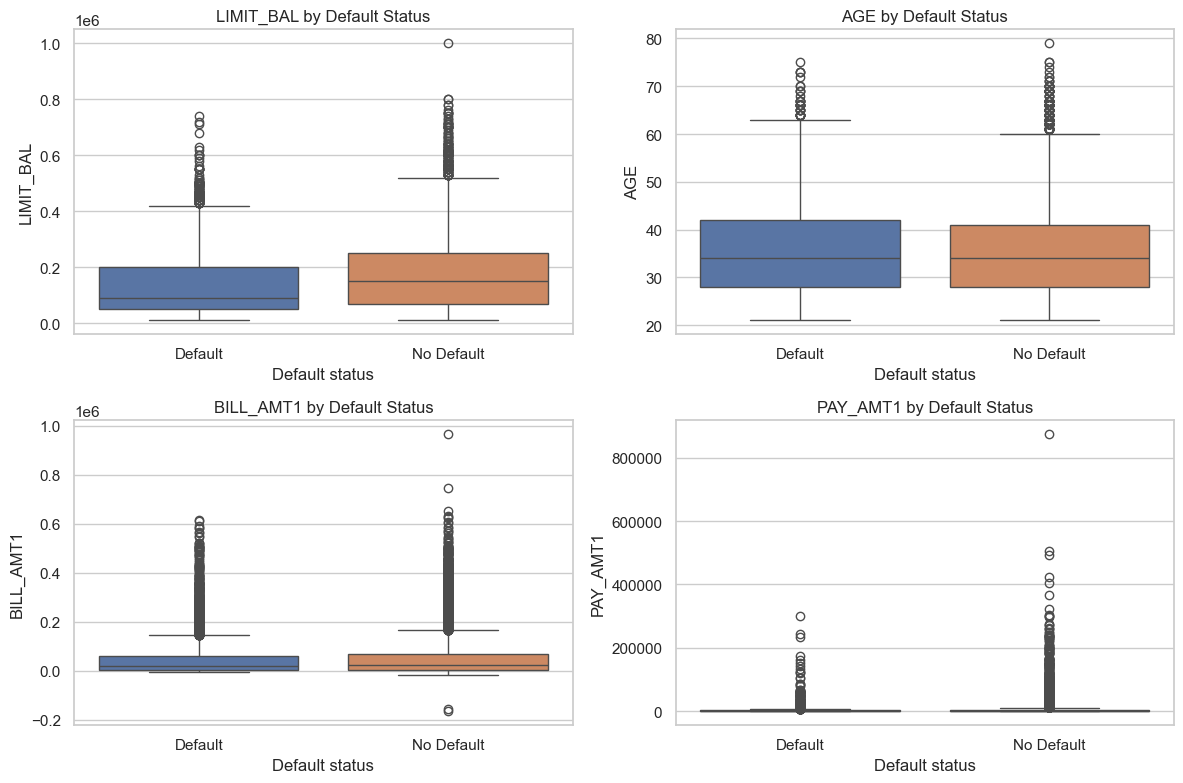

default_label,Default,No Default
PAY_0,0.668174,-0.211222
PAY_2,0.458258,-0.301917
PAY_3,0.362116,-0.316256
PAY_4,0.254521,-0.355633
PAY_5,0.167872,-0.389488
PAY_6,0.112116,-0.405624


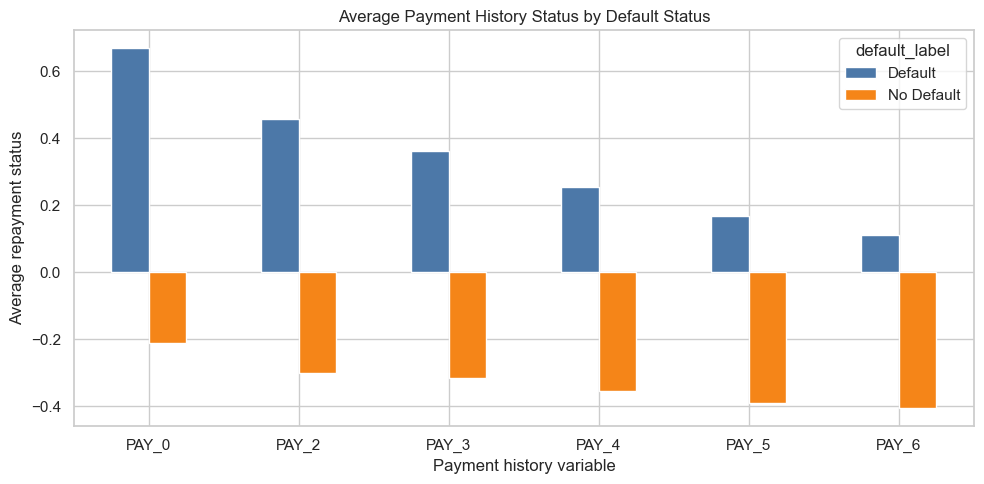

In [30]:
# Boxplots comparing selected variables by default status.
plot_df = df.copy()
plot_df["default_label"] = plot_df["default_next_month"].map({0: "No Default", 1: "Default"})

boxplot_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, boxplot_features):
    sns.boxplot(data=plot_df, x="default_label", y=feature, hue="default_label", ax=ax, legend=False)
    ax.set_title(f"{feature} by Default Status")
    ax.set_xlabel("Default status")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# Payment history comparison by default status.
payment_history_features = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
payment_history_means = plot_df.groupby("default_label")[payment_history_features].mean().T

display(payment_history_means)

payment_history_means.plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#F58518"])
plt.title("Average Payment History Status by Default Status")
plt.xlabel("Payment history variable")
plt.ylabel("Average repayment status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Cleaning and Preprocessing Plan

Preprocessing should handle missing values, categorical variables, and scaling. Use `Pipeline` and `ColumnTransformer` so preprocessing is applied correctly inside cross-validation.

**Categorical features to consider one-hot encoding:** sex, education, marriage.  
**Features that may need scaling:** all numeric features for Logistic Regression, KNN, SVM, and MLP-style models.  
**Tree-based models:** Decision Tree, Random Forest, and Gradient Boosting generally do not require scaling.

In [31]:
# Define feature groups for preprocessing.
# SEX, EDUCATION, and MARRIAGE are numeric codes, but they represent categories.
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numerical_features = [col for col in X.columns if col not in categorical_features]

feature_groups = pd.DataFrame({
    "feature_group": ["Categorical", "Numerical"],
    "columns": [", ".join(categorical_features), ", ".join(numerical_features)],
    "count": [len(categorical_features), len(numerical_features)],
})

display(feature_groups)

,feature_group,columns,count
0,Categorical,"SEX, EDUCATION, MARRIAGE",3
1,Numerical,"LIMIT_BAL, AGE, PAY_0, PAY_2, PAY_3, PAY_4, PA...",20


In [32]:
# Build preprocessing transformers.
# The scaled preprocessor is useful for Logistic Regression, KNN, SVM, and similar models.
numeric_scaled_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# The unscaled numeric preprocessor is useful for tree-based models.
numeric_unscaled_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

scaled_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_scaled_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features),
])

tree_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_unscaled_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features),
])

# Default preprocessor used by later placeholder model code.
preprocessor = scaled_preprocessor

print("Scaled preprocessor ready for distance/magnitude-sensitive models.")
print("Tree preprocessor ready for tree-based models.")

Scaled preprocessor ready for distance/magnitude-sensitive models.
Tree preprocessor ready for tree-based models.


## 8. Classifiers to Compare

Minimum model set from the project plan:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors
- Gradient Boosting

Optional models if time allows:

- Naive Bayes
- Support Vector Machine
- Neural Network / Multi-layer Perceptron

In [37]:
# TODO: Define models for comparison.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    #"Naive Bayes": GaussianNB(),
    #"SVM": SVC(probability=True, random_state=RANDOM_STATE),
}
i = 0

## 9. Evaluation Strategy

Use stratified k-fold cross-validation because the default class may be imbalanced. Report mean and standard deviation for each metric.

**Metrics:** accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix.

Recall and F1-score should receive extra attention because missing actual defaulters can be costly.

In [38]:
# TODO: Set up stratified k-fold cross-validation and scoring metrics.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

In [39]:
# TODO: Run cross-validation for each classifier using a pipeline.

cv_results = []
for model_name, model in models.items():
    print("Running cross validation for model ", model_name)
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    # TODO: Store mean and standard deviation for each metric.
    for metric in scoring:
        cv_results.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": scores[f"test_{metric}"].mean(),
            "Std": scores[f"test_{metric}"].std()
        })

results_df = pd.DataFrame(cv_results)
display(results_df)

Running cross validation for model  Logistic Regression
Running cross validation for model  Decision Tree
Running cross validation for model  Random Forest
Running cross validation for model  KNN
Running cross validation for model  Gradient Boosting


,Model,Metric,Mean,Std
0,Logistic Regression,accuracy,0.811200,0.001756
1,Logistic Regression,precision,0.715214,0.011001
2,Logistic Regression,recall,0.243369,0.005254
3,Logistic Regression,f1,0.363151,0.007035
4,Logistic Regression,roc_auc,0.724114,0.004502
5,Decision Tree,accuracy,0.727400,0.003476
6,Decision Tree,precision,0.389625,0.007537
7,Decision Tree,recall,0.410188,0.009084
8,Decision Tree,f1,0.399637,0.008162
9,Decision Tree,roc_auc,0.614095,0.005711


## 10. Model Comparison Results

Use this section for the final cross-validation comparison table.

| Classifier | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.811200 +/- 0.001756 | 0.715214 +/- 0.011001 | 0.243369 +/- 0.005254 | 0.363151 +/- 0.007035 | 0.724114 +/- 0.004502 |
| Decision Tree | 0.727400 +/- 0.003476 | 0.389625 +/- 0.007537 | 0.410188 +/- 0.009084 | 0.399637 +/- 0.008162 | 0.614095 +/- 0.00571 |
| Random Forest | 0.816367 +/- 0.003939 | 0.648825 +/- 0.014874| 0.370856 +/- 0.004349 | 0.471881 +/- 0.005324 | 0.765705 +/- 0.003766 |
| KNN | 0.792600 +/- 0.003209 | 0.548388 +/- 0.012302 | 0.355334 +/- 0.004976 | 0.431170 +/- 0.005368 | 0.701030 +/- 0.005711 |
| Gradient Boosting | 0.820767 +/- 0.004189 | 0.675624 +/- 0.020624 | 0.365431 +/- 0.006140 | 0.474278 +/- 0.009801 | 0.781162 +/- 0.005578 |

## 11. Best Model Evaluation

After comparing cross-validation results, select the best model based on F1-score, recall, and ROC-AUC. If time allows, evaluate the selected model on a final holdout test set.

In [45]:
# TODO: Optional holdout test evaluation for the selected model.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

best_model = GradientBoostingClassifier(random_state=RANDOM_STATE)  # TODO: Replace with selected model pipeline.
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7784495613741561


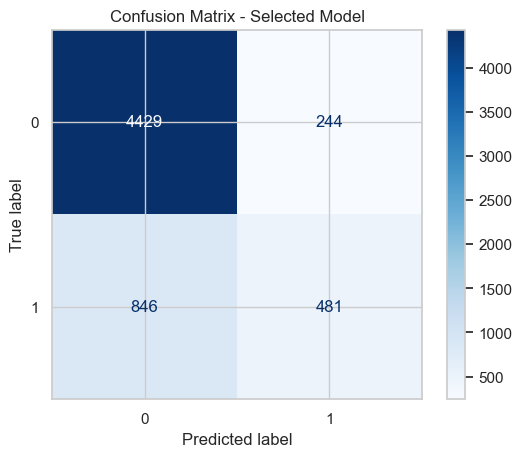

In [46]:
# TODO: Plot confusion matrix for the selected model.

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Selected Model")
plt.show()

## 12. Feature Importance and Interpretability

Use this section to explain what the model learned.

Possible methods:

- Logistic regression coefficients
- Random Forest or Gradient Boosting feature importance
- Confusion matrix error discussion

Discussion questions:

- Are payment history features more important than demographic features?
- Does credit limit strongly affect default prediction?
- Are previous bill/payment amounts useful?
- Are there signs that demographic variables affect predictions?

,feature,importance
5,PAY_0,0.634715
6,PAY_2,0.076458
11,BILL_AMT1,0.037117
7,PAY_3,0.034016
0,LIMIT_BAL,0.027840
19,PAY_AMT3,0.024142
18,PAY_AMT2,0.020707
9,PAY_5,0.019506
8,PAY_4,0.018384
17,PAY_AMT1,0.016955


C:\Users\Ryan\AppData\Local\Temp\ipykernel_64328\2731230372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x="importance", y="feature", palette="viridis")


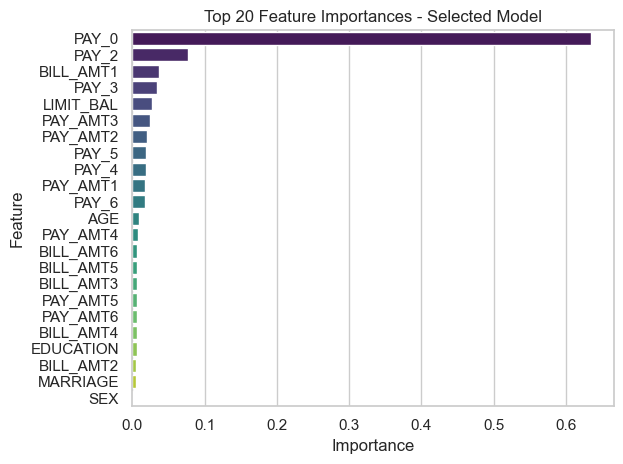

In [ ]:
# TODO: Create feature importance or coefficient plot for the selected model.

# Example placeholder for tree-based models:
#importances = best_model.named_steps["model"].feature_importances_
feature_names = best_model.feature_names_in_
importances = best_model.feature_importances_
# TODO: Match importances to processed feature names before plotting.
importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)
#display(importances_df)
sns.barplot(data=importances_df, x="importance", y="feature", palette="viridis")
plt.title("Top 20 Feature Importances - Selected Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 13. Findings and Discussion

Use this section to summarize the main results after the models are trained.

Prompts to answer later:

- Which classifier performed best overall?
- Did cross-validation results seem consistent across folds?
- Which metric was most useful for this problem?
- What features seemed most useful for predicting default risk?
- Was a more complex model clearly better than a simpler baseline?

## 14. Scope Limits and Future Work

Possible future work:

- More detailed fairness analysis across demographic groups
- Hyperparameter tuning with grid search or randomized search
- Additional models such as XGBoost, LightGBM, or neural networks
- Cost-sensitive learning that penalizes false negatives more heavily
- Threshold tuning to improve recall for default cases
- More advanced feature engineering
- Model calibration for more accurate default probabilities

## 15. Conclusion

Write a short final conclusion after completing the analysis. Mention the selected model, key metrics, important features, limitations, and what the results mean for the stakeholders.